In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from src.train import train
from src.scp_core import uniform_sample_bright_side, rwm_bright_side, SCP

In [3]:
d = 10
latitude = 1.5
scp = SCP(d, latitude=latitude)

Specify target density

In [4]:
_observer = jnp.linspace(-1, 1, d)
_observer *= jnp.sqrt((0.95 - (1 - latitude)**2) / jnp.sum(_observer**2))
print(jnp.sum(_observer**2) + (latitude - 1)**2)
target_params = scp.inverse_transform_params(_observer, 
                                             shift=jnp.zeros(d), 
                                             scale=1.)

def target_logp(x):
    return scp.log_prob(target_params, x)

0.95000005


Visualize target distribution

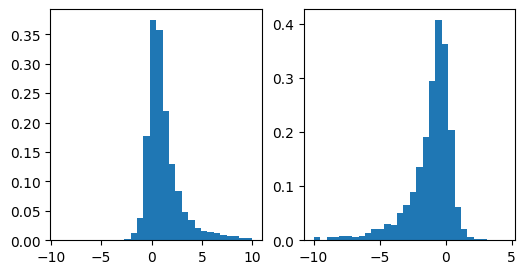

In [5]:
key = jax.random.key(0)
exact_samples = scp.sample(target_params, key, n=5000)

fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].hist(exact_samples[abs(exact_samples[:, 0]) < 10 , 0], 30, density=True)
ax[1].hist(exact_samples[abs(exact_samples[:, -1]) < 10 , -1], 30, density=True)
plt.show()

Initialize parameters and samples

In [ ]:
seed = 1
ntrain = 5000
X = uniform_sample_bright_side(d, latitude, jax.random.key(seed), n=ntrain)

params = {
    'observer': jnp.zeros(d),
    'shift': jnp.zeros(d),
    'scale': 0.
}

Define loss function as the reverse KL

In [7]:
@jax.jit
def loss_fn(params, X):
    return scp.reverse_kl(params, target_logp, X)

opt_params, losses = train(lambda params: loss_fn(params, X), params, learning_rate=0.01, max_iter=1000)

Running for 1,000 iterations: 100%|██████████| 1000/1000 [00:00<00:00, 1454.64it/s]


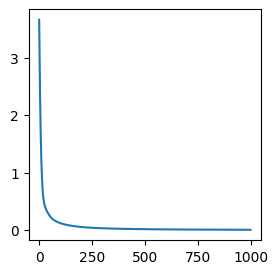

In [8]:
plt.figure(figsize=(3, 3))
plt.plot(losses)

In [9]:
scp.transform_params(opt_params), scp.transform_params(target_params)

((Array([-0.39677775, -0.29745167, -0.21773434, -0.12796776, -0.04244794,
          0.04735612,  0.12779334,  0.20628348,  0.304104  ,  0.37384567],      dtype=float32),
  Array([ 0.02860155,  0.01878378,  0.00799526,  0.00561994,  0.00164215,
          0.00325023, -0.01334992, -0.03175564, -0.03113881, -0.04213291],      dtype=float32),
  Array(0.99071044, dtype=float32)),
 (Array([-0.41450956, -0.32239634, -0.23028311, -0.13816984, -0.04605663,
          0.04605664,  0.13816987,  0.23028311,  0.32239634,  0.41450956],      dtype=float32),
  Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
  Array(1., dtype=float32, weak_type=True)))

In [10]:
transformed_samples = scp.projection(opt_params, X)

Visualize transformed samples with the learned parameters

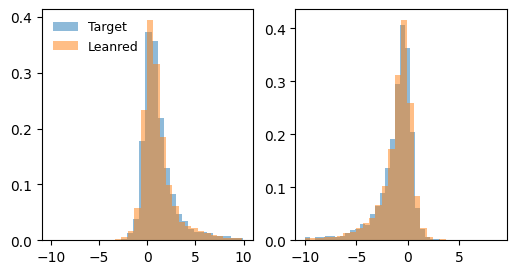

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].hist(exact_samples[abs(exact_samples[:, 0]) < 10 , 0], 30, density=True, alpha=.5, label='Target')
ax[0].hist(transformed_samples[abs(transformed_samples[:, 0]) < 10 , 0], 30, density=True, alpha=.5, label='Leanred')

ax[1].hist(exact_samples[abs(exact_samples[:, -1]) < 10 , -1], 30, density=True, alpha=.5)
ax[1].hist(transformed_samples[abs(transformed_samples[:, -1]) < 10 , -1], 30, density=True, alpha=.5)

ax[0].legend(loc='upper left', fontsize=9, frameon=False)
plt.show()

In [12]:
logp_sphere = scp.transform_target(target_logp, opt_params)

nsample = 5000
burnin = 500
x0 = jnp.zeros(d+1)
mcmc_samples_sphere, accepts = rwm_bright_side(logp_sphere, x0, latitude, key=jax.random.key(10), nsample=nsample+burnin, stepsize=0.5)

In [13]:
mcmc_samples = scp.projection(opt_params, mcmc_samples_sphere[burnin:])

In [14]:
accepts.mean()

Array(0.91690904, dtype=float32)

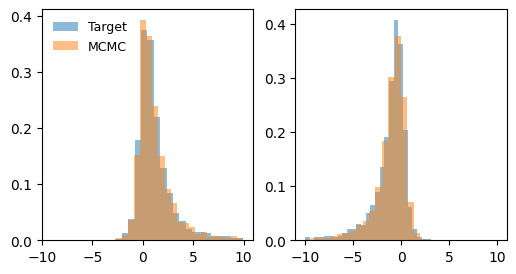

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].hist(exact_samples[abs(exact_samples[:, 0]) < 10 , 0], 30, density=True, alpha=.5, label='Target')
ax[0].hist(mcmc_samples[abs(mcmc_samples[:, 0]) < 10 , 0], 30, density=True, alpha=.5, label='MCMC')

ax[1].hist(exact_samples[abs(exact_samples[:, -1]) < 10 , -1], 30, density=True, alpha=.5)
ax[1].hist(mcmc_samples[abs(mcmc_samples[:, -1]) < 10, -1], 30, density=True, alpha=.5)

ax[0].legend(loc='upper left', fontsize=9, frameon=False)
plt.show()

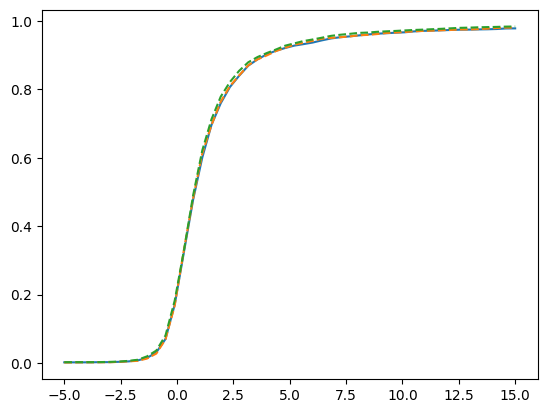

In [16]:
xx = jnp.linspace(-5, 15, 50)
plt.plot(xx, [jnp.mean(exact_samples[:, 0] <= x) for x in xx])
plt.plot(xx, [jnp.mean(mcmc_samples[:, 0] <= x) for x in xx], ls='--')
plt.plot(xx, [jnp.mean(transformed_samples[:, 0] <= x) for x in xx], ls='--')

In [17]:
jnp.quantile(exact_samples[:, 0], jnp.array([0.025, 0.975]))

Array([-1.0351158, 12.762118 ], dtype=float32)

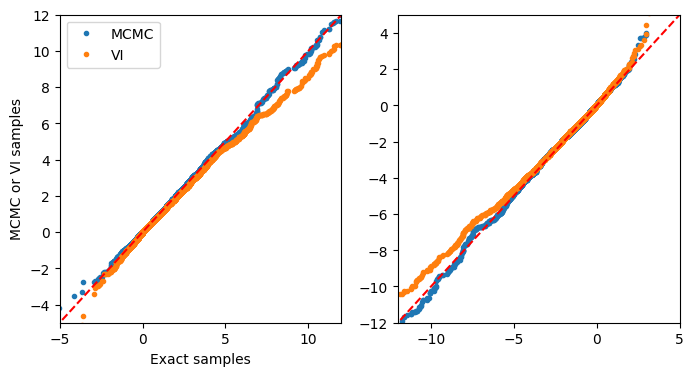

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
for i, j in enumerate([0, d-1]):
    exact_sorted = jnp.sort(exact_samples[:, j])
    mcmc_sorted = jnp.sort(mcmc_samples[:, j])
    vi_sorted = jnp.sort(transformed_samples[:, j])
    ax[i].plot(exact_sorted, mcmc_sorted, '.', label='MCMC')
    ax[i].plot(exact_sorted, vi_sorted, '.', label='VI')
    ax[i].plot([-15, 15], [-15, 15], 'r--')  # Reference line for y=x

ax[0].set_xlim(-5., 12)
ax[0].set_ylim(-5., 12)
ax[1].set_xlim(-12., 5)
ax[1].set_ylim(-12., 5)
ax[0].set_xlabel('Exact samples')
ax[0].set_ylabel('MCMC or VI samples')
ax[0].legend()

## Skewed $t$

In [35]:
import numpy as np
from scipy.stats import jf_skew_t #, skewcauchy

In [210]:
d = 5
a = np.linspace(1, 2, d)
b = np.linspace(2, 1, d)
target_skewt = jf_skew_t(a, b)
exact_samples = target_skewt.rvs((5000, d))

def target_logp(x):
    # return target_skewt.logpdf(x).sum(-1)
    logp = (a + 0.5) * jnp.log(1 + x / jnp.sqrt(a + b + x**2)) + (b + .5) * jnp.log(1 - x / jnp.sqrt(a + b + x**2))
    return logp.sum(-1)

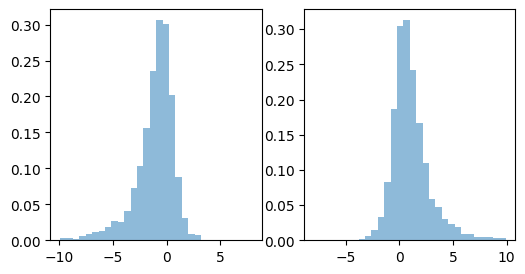

In [211]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].hist(exact_samples[abs(exact_samples[:, 0]) < 10 , 0], 30, density=True, alpha=.5)
ax[1].hist(exact_samples[abs(exact_samples[:, -1]) < 10 , -1], 30, density=True, alpha=.5)
plt.show()

In [ ]:
seed = 4
ntrain = 5000
latitude = 1.8 
scp = SCP(d, latitude)
X = uniform_sample_bright_side(d, latitude, jax.random.key(seed), n=ntrain)

params = {
    'observer': jnp.zeros(d),
    'shift': jnp.zeros(d),
    'scale': 0.
}

@jax.jit
def loss_fn(params, X):
    return scp.reverse_kl(params, target_logp, X)

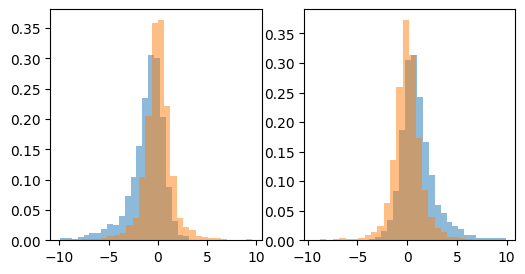

In [239]:
initial_samples = scp.projection(params, X)
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].hist(exact_samples[abs(exact_samples[:, 0]) < 10 , 0], 30, density=True, alpha=.5)
ax[0].hist(initial_samples[abs(initial_samples[:, 0]) < 10 , 0], 30, density=True, alpha=.5)
ax[1].hist(exact_samples[abs(exact_samples[:, -1]) < 10 , -1], 30, density=True, alpha=.5)
ax[1].hist(initial_samples[abs(initial_samples[:, -1]) < 10 , -1], 30, density=True, alpha=.5)
plt.show()

In [240]:
opt_params, losses = train(lambda params: loss_fn(params, X), params, learning_rate=0.01, max_iter=1000)

Running for 1,000 iterations: 100%|██████████| 1000/1000 [00:00<00:00, 2723.48it/s]


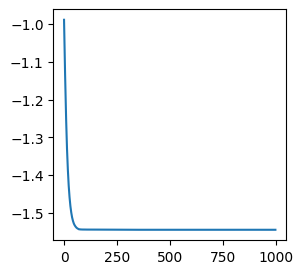

In [241]:
plt.figure(figsize=(3, 3))
plt.plot(losses)

In [242]:
jnp.sum(scp.transform_params(opt_params)[0]**2) + (latitude - 1)**2

Array(0.73698264, dtype=float32)

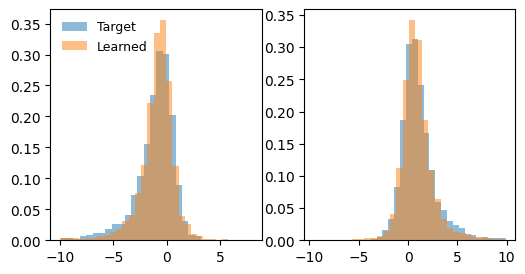

In [243]:
transformed_samples = scp.projection(opt_params, X)
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].hist(exact_samples[abs(exact_samples[:, 0]) < 10 , 0], 30, density=True, alpha=.5, label='Target')
ax[0].hist(transformed_samples[abs(transformed_samples[:, 0]) < 10 , 0], 30, density=True, alpha=.5, label='Learned')
ax[1].hist(exact_samples[abs(exact_samples[:, -1]) < 10 , -1], 30, density=True, alpha=.5, label='Target')
ax[1].hist(transformed_samples[abs(transformed_samples[:, -1]) < 10 , -1], 30, density=True, alpha=.5, label='Learned')
ax[0].legend(loc='upper left', fontsize=9, frameon=False)
plt.show()

In [244]:
logp_sphere = scp.transform_target(target_logp, opt_params)

nsample = 5000
burnin = 500
x0 = jnp.zeros(d+1)
mcmc_samples_sphere, accepts = rwm_bright_side(logp_sphere, x0, latitude, key=jax.random.key(10), nsample=nsample+burnin, stepsize=0.5)

In [245]:
mcmc_samples = scp.projection(opt_params, mcmc_samples_sphere[burnin:])

In [246]:
accepts.mean()

Array(0.6001818, dtype=float32)

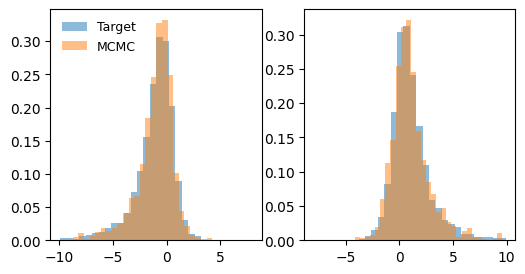

In [247]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].hist(exact_samples[abs(exact_samples[:, 0]) < 10 , 0], 30, density=True, alpha=.5, label='Target')
ax[0].hist(mcmc_samples[abs(mcmc_samples[:, 0]) < 10 , 0], 30, density=True, alpha=.5, label='MCMC')

ax[1].hist(exact_samples[abs(exact_samples[:, -1]) < 10 , -1], 30, density=True, alpha=.5)
ax[1].hist(mcmc_samples[abs(mcmc_samples[:, -1]) < 10, -1], 30, density=True, alpha=.5)

ax[0].legend(loc='upper left', fontsize=9, frameon=False)
plt.show()

In [248]:
jnp.quantile(exact_samples[:, 0], jnp.array([0.025, 0.975]))

Array([-7.2932615,  1.5192952], dtype=float32)

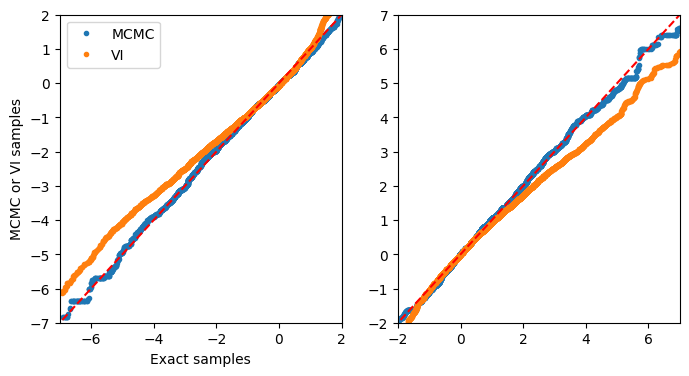

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
for i, j in enumerate([0, d-1]):
    exact_sorted = jnp.sort(exact_samples[:, j])
    mcmc_sorted = jnp.sort(mcmc_samples[:, j])
    vi_sorted = jnp.sort(transformed_samples[:, j])
    ax[i].plot(exact_sorted, mcmc_sorted, '.', label='MCMC')
    ax[i].plot(exact_sorted, vi_sorted, '.', label='VI')
    ax[i].plot([-15, 15], [-15, 15], 'r--')  # Reference line for y=x

ax[0].set_xlim(-7., 2)
ax[0].set_ylim(-7., 2)
ax[1].set_xlim(-2., 7)
ax[1].set_ylim(-2., 7)
ax[0].set_xlabel('Exact samples')
ax[0].set_ylabel('MCMC or VI samples')
ax[0].legend()

TODO:
- Competing methods: naive RWM, NUTS
- Metrics to evaluate
- Target distributions
- Tuning parameters: latitude, RWM step size
- Optimizing SCP and NF simultaneously